In [6]:
#pip install pymongo
#pip install pyarrow

# 1. Import Libraries

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
from pymongo import MongoClient
from pymongo.errors import ConnectionFailure

# 2. Import Data

In [4]:
df = pd.read_parquet('DataSet\yellow_tripdata_2026-05.parquet')

In [5]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,35.9,6.00,0.5,0.00,0.0,1.0,45.40,0.0,2.0,0.00
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,27.5,6.00,0.5,9.56,0.0,1.0,49.81,2.5,2.0,0.75
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,19.1,4.25,0.5,3.73,0.0,1.0,28.58,2.5,0.0,0.75
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.20,1.0,N,232,114,1,9.3,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75
4,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,7.2,0.00,0.5,2.44,0.0,1.0,14.64,2.5,0.0,0.00


# 3. Summarize Data

In [43]:
# 1.size
df.shape

(4090836, 20)

In [44]:
# datatypes
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4090836 entries, 0 to 4090835
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [31]:
# missing values
df.isna().sum()

na_counts = df.isna().sum()

na_pct = df.isna().sum().div(df.shape[0]).mul(100).round(2)

na_df = (
    pd
    .concat([na_counts,na_pct],axis=1)
    .set_axis(["count","pct"],axis=1)
    .query("count > 0")
)
na_df

,count,pct
passenger_count,955371,23.35
RatecodeID,955371,23.35
store_and_fwd_flag,955371,23.35
congestion_surcharge,955371,23.35
Airport_fee,955371,23.35


In [32]:
# duplicate values
df.duplicated().sum()

np.int64(0)

# 4. Load data to MongoDB


In [9]:
# establish connection to MongoDB local Server

try:
    client = MongoClient('mongodb://localhost:27017/')
    db = client['taxis']
except ConnectionFailure as e:
    print(f'Error while connecting :{e}')
else:
    print('Connection Successful')
    collection = db['taxi_data']

Connection Successful


In [10]:
import time

start_time = time.perf_counter()
data_json = df.to_dict(orient='records')
end_time = time.perf_counter()

print(f"Time taken: {end_time - start_time:.6f} seconds")

Time taken: 26.252965 seconds


In [49]:
# insert data in collection

start_time = time.perf_counter()
collection.insert_many(data_json)
end_time = time.perf_counter()

print(f'Data loaded into MongoDB in {end_time - start_time:.6f} seconds')

Data loaded into MongoDB in 75.486519 seconds


# 5. Query and Visualization

In [11]:
df.sample(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1146090,1,2026-05-12 09:18:27,2026-05-12 09:27:08,1.0,1.00,1.0,N,170,234,1,8.6,3.25,0.5,1.00,0.0,1.0,14.35,2.5,0.0,0.75
941855,2,2026-05-10 00:12:12,2026-05-10 00:24:58,1.0,2.06,1.0,N,79,170,1,12.8,1.00,0.5,3.71,0.0,1.0,22.26,2.5,0.0,0.75


## Q1 : What are the Peak time for Taxi Pickup?

In [12]:
# query

q1 = collection.aggregate([

    {
        "$project": {"hour":{"$hour" : "$tpep_pickup_datetime"}}
    },
    {
        "$group": {
            "_id": "$hour",
            "pickup_count":{"$count":{}}
           }
    },
    {
        "$sort":{"_id": 1}
    }
    
         
])
df1 = pd.DataFrame(q1)
df1

,_id,pickup_count
0,0,125782
1,1,83806
2,2,56451
3,3,39496
4,4,32504
5,5,36398
6,6,67608
7,7,124354
8,8,160502
9,9,171880


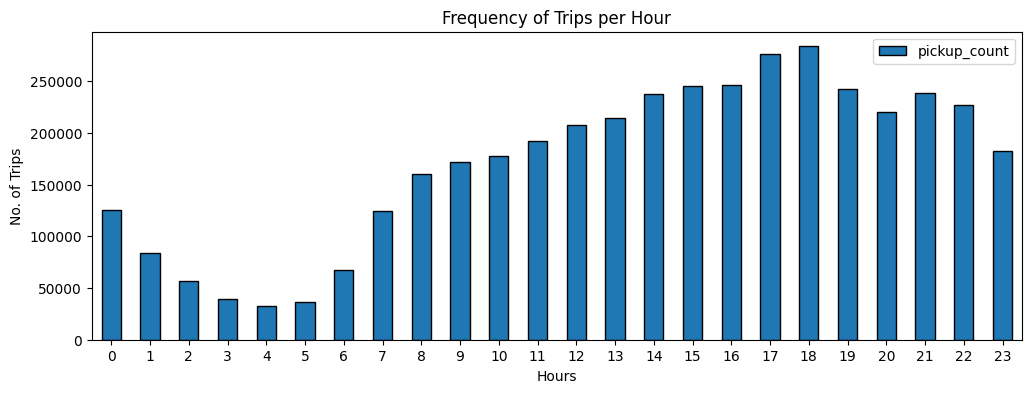

In [13]:
# plot

fig,ax = plt.subplots()

(
    df1
    .rename(columns={"_id":"hour"})
    .set_index("hour")
    .plot(
        kind='bar',
        ax=ax,
        figsize=(12,4),
        xlabel='Hours',
        ylabel='No. of Trips',
        title='Frequency of Trips per Hour',
        edgecolor = 'black',
        rot=0
        
    )
    
)


plt.show()

## Q2 . What is the Average trip distance by passenger count?

In [75]:
q2= collection.aggregate([
    {
        "$group":{
            "_id":"$passenger_count",
            "Avg_trip_distance":{"$avg":"$trip_distance"}
        }
    },
    {
        "$sort":{"_id":1}
    }
    
])

df2=pd.DataFrame(q2)
df2

,_id,Avg_trip_distance
0,NaN,10.095261
1,0.0,2.541361
2,1.0,3.321436
3,2.0,3.819226
4,3.0,3.538642
5,4.0,3.492286
6,5.0,2.742008
7,6.0,3.424988
8,8.0,0.873333
9,9.0,0.000000


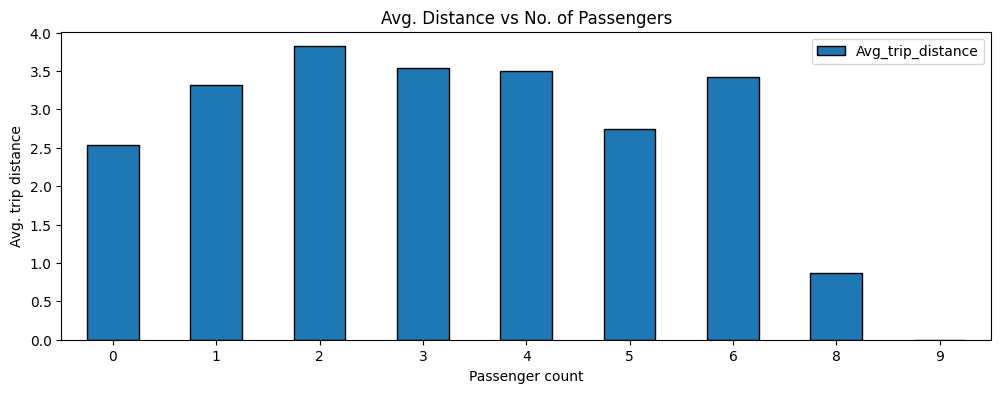

In [97]:
# plot

fig,ax = plt.subplots()

(
    df2
    .rename(columns={"_id":"Passenger_count"})
    .dropna()
    .assign(Passenger_count=lambda x:x.Passenger_count.astype(int))
    .set_index("Passenger_count")
    .plot(
        kind='bar',
        ax=ax,
        figsize=(12,4),
        xlabel='Passenger count',
        ylabel='Avg. trip distance',
        title='Avg. Distance vs No. of Passengers',
        edgecolor = 'black',
        rot=0
        
    )
    
)


plt.show()

## Q3. What is the Distribution of Payment Types

In [105]:
q3 = collection.aggregate([
    {
        "$group":{
            "_id": "$payment_type",
            "Cnt_of_Payment_Type":{"$count":{}}
        }
    },
    {
        "$sort":{"_id":1}
    }
    
])

df3 = pd.DataFrame(q3)
df3

,_id,Cnt_of_Payment_Type
0,0,955371
1,1,2727585
2,2,372909
3,3,11984
4,4,22987


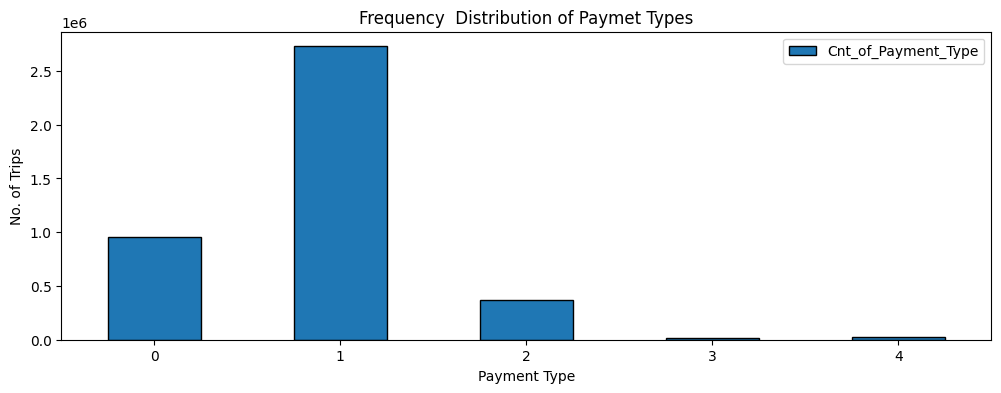

In [156]:
# plot

fig,ax = plt.subplots()

(
    df3
    .rename(columns={"_id":"Payment_Type"})
    .dropna()
    .assign(Payment_Type=lambda x:x.Payment_Type.astype(int))
    .set_index("Payment_Type")
    .plot(
        kind='bar',
        ax=ax,
        figsize=(12,4),
        xlabel='Payment Type',
        ylabel='No. of Trips',
        title='Frequency  Distribution of Paymet Types',
        edgecolor = 'black',
        rot=0
        
    )
    
)


plt.show()

## Q4. What are the top 10 days with highest number of trips?

In [116]:
df.sample(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2292151,2,2026-05-22 15:27:17,2026-05-22 15:32:17,2.0,0.73,1.0,N,239,142,1,7.20,0.0,0.5,1.50,0.0,1.0,12.70,2.5,0.0,0.0
3761604,2,2026-05-21 08:45:00,2026-05-21 09:07:00,NaN,2.22,NaN,None,143,141,0,24.34,0.0,0.5,5.67,0.0,1.0,34.01,NaN,NaN,0.0


In [14]:
# query

q4 = collection.aggregate([
    {
        "$project":{"day_of_month":{"$dayOfMonth":"$tpep_pickup_datetime"}}
    },
    {
        "$group":{
            "_id":"$day_of_month",
            "No_of_Trips":{"$count":{}}
        }
    },
    {
        "$sort":{"No_of_Trips":-1}
    },
    {
        "$limit":10
    }
    
])

df4 = pd.DataFrame(q4)
df4

,_id,No_of_Trips
0,14,163437
1,15,155772
2,16,155330
3,20,155286
4,13,149138
5,21,145999
6,19,144846
7,28,142535
8,30,142482
9,12,141444


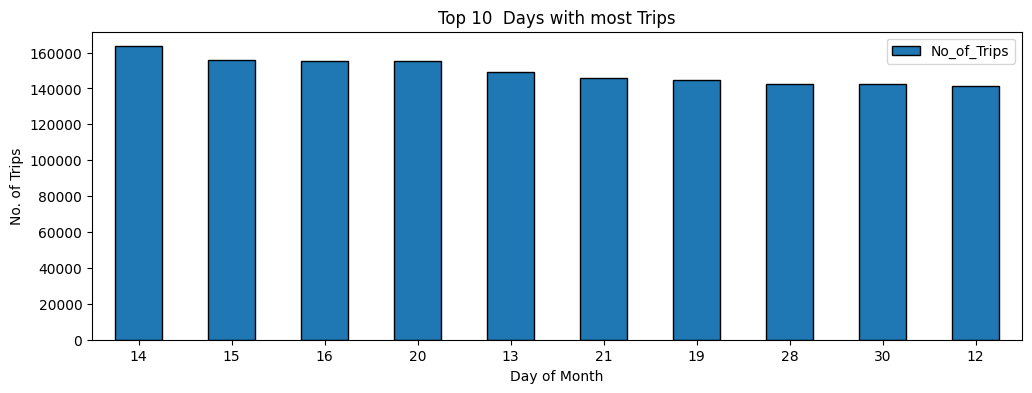

In [15]:
# plot

fig,ax = plt.subplots()

(
    df4
    .rename(columns={"_id":"Day of Month"})
    .set_index("Day of Month")
    .plot(
        kind='bar',
        ax=ax,
        figsize=(12,4),
        xlabel='Day of Month',
        ylabel='No. of Trips',
        title='Top 10  Days with most Trips',
        edgecolor = 'black',
        rot=0
        
    )
    
)


plt.show()

## Q5. What is Total Fare collected by each payment type?

In [128]:
q5 = collection.aggregate([
    {
        "$group":{
            "_id":"$payment_type",
            "Total_fare":{"$sum":"$total_amount"}
        }
    },
    {
        "$sort":{"_id":1}
    }
])
df5 = pd.DataFrame(q5)
df5

,_id,Total_fare
0,0,31278564.95
1,1,83607506.34
2,2,9532186.16
3,3,170693.57
4,4,120770.41


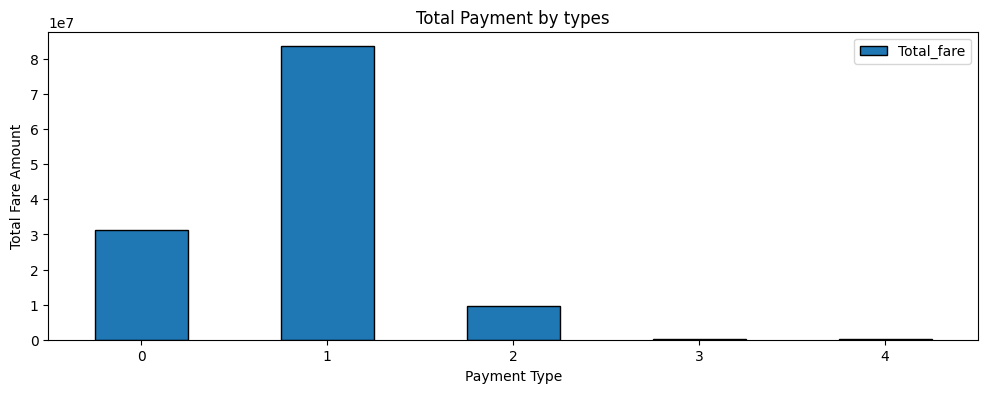

In [155]:
# plot

fig,ax = plt.subplots()

(
    df5
    .rename(columns={"_id":"Payment Type"})
    .set_index("Payment Type")
    .plot(
        kind='bar',
        ax=ax,
        figsize=(12,4),
        xlabel='Payment Type',
        ylabel='Total Fare Amount',
        title='Total Payment by types',
        edgecolor = 'black',
        rot=0
        
    )
    
)


plt.show()

## Q6. What are the Avg Trip distance for each hour of the day?


In [17]:
#query
q6 = collection.aggregate([
    {
        "$project":{
            "hour": {"$hour":"$tpep_pickup_datetime"},
            "trip_distance" :True
            
        }
    },
    {
        "$group":
        {
            "_id":"$hour",
            "Avg_distance":{"$avg":"$trip_distance"}
        }
    },
    {
        "$sort":
        {"_id":1}
    }

    
])
df6 = pd.DataFrame(q6)
df6

,_id,Avg_distance
0,0,11.893074
1,1,3.623180
2,2,3.559906
3,3,14.022345
4,4,12.119101
5,5,5.972068
6,6,9.818550
7,7,13.162932
8,8,3.921513
9,9,4.378055


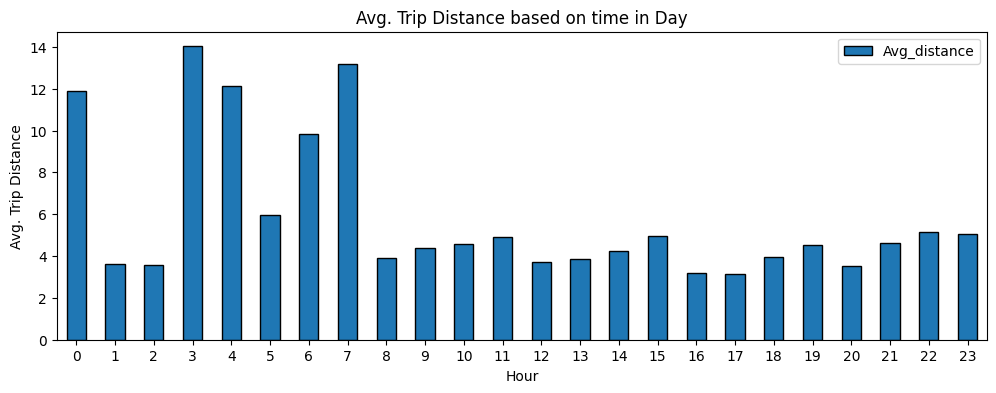

In [18]:
# plot

fig,ax = plt.subplots()

(
    df6
    .rename(columns={"_id":"Hour of Day"})
    .set_index("Hour of Day")
    .plot(
        kind='bar',
        ax=ax,
        figsize=(12,4),
        xlabel='Hour',
        ylabel='Avg. Trip Distance',
        title='Avg. Trip Distance based on time in Day',
        edgecolor = 'black',
        rot=0
        
    )
    
)


plt.show()

## Q7. What is the distribution of trips by passenger counts


In [147]:
# query

q7 = collection.aggregate([
    {
        "$group":
        {
            "_id":"$passenger_count",
            "Count_of_passengers":{"$count":{}}
        }
    },
    {
        "$sort":
        {
            "_id":1
        }
    }
])

df7 = pd.DataFrame(q7)
df7

,_id,Count_of_passengers
0,NaN,955371
1,0.0,12533
2,1.0,2578718
3,2.0,395103
4,3.0,83959
5,4.0,52929
6,5.0,7666
7,6.0,4553
8,8.0,3
9,9.0,1


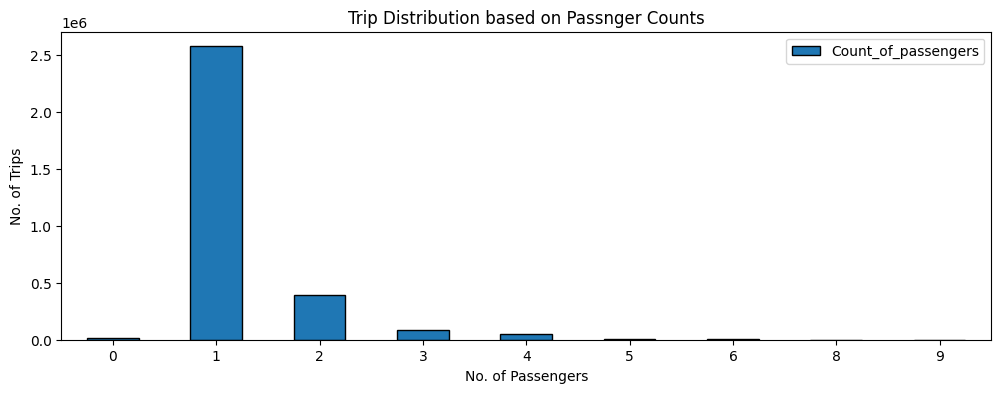

In [153]:
# plot

fig,ax = plt.subplots()

(
    df7
    .dropna()
    .apply(lambda x:x.astype(int))
    .rename(columns={"_id":"Passenger Counts"})
    .set_index("Passenger Counts")
    .plot(
        kind='bar',
        ax=ax,
        figsize=(12,4),
        xlabel='No. of Passengers',
        ylabel='No. of Trips',
        title='Trip Distribution based on Passnger Counts',
        edgecolor = 'black',
        rot=0
        
    )
    
)


plt.show()